In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
if size(LOAD_PATH,1) < 4    
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end

  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

In [3]:
include("../scripts/TesselationCore.jl")
import .TesselationCore

BVH = TesselationCore.BVH
point3 = TesselationCore.point3

SVector{3, Float64} (alias for SArray{Tuple{3}, Float64, 1, 3})

In [4]:
import illustris_julia as il


#basePath = "../../ThesisMaster/Illustris/"; #virgo
basePath = "../../DTFE/Illustris3/output"; # laptop


fields = ["SubhaloMass","SubhaloCM"];
subhalos = il.groupcat.loadSubhalos(basePath,135,fields)

positions = subhalos["SubhaloCM"]
print("done") #otherwise floods GitHub with output 

done

In [5]:
gap = 1
points = positions[:,1:gap:end]
ps = [point3(points[1,i], points[2,i], points[3,i]) for i in 1:size(points,2)]

bvh,tes,tets = TesselationCore.standardEstimator(ps,10)
print("done")

done

In [6]:
N = 256

width = 75000

step = width/N


xs = bvh.bbox[1,1]:step:bvh.bbox[1,2]
ys = bvh.bbox[2,1]:step:bvh.bbox[2,2]

z = (bvh.bbox[3,2] + bvh.bbox[3,1])/2

dens = TesselationCore.DTFEMultiThread([xs,ys,z],bvh,tets,tes)
med = median(dens)

0.0

In [15]:
den = dens[:,:,1]
med = median(den)

1.703787640897717e-12

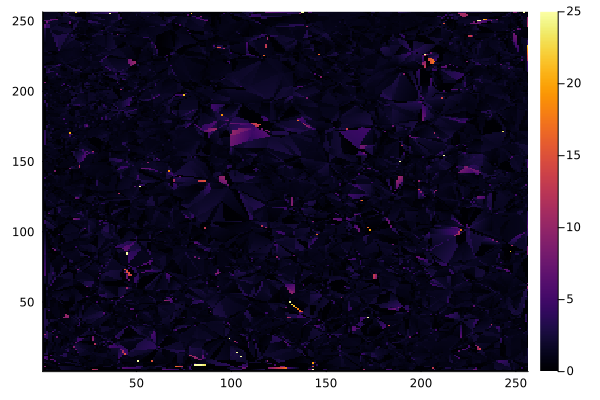

In [16]:
Plots.heatmap(den ./med,clim=(0,25))

In [ ]:
N = 128

width = 75000

step = width/N


xs = bvh.bbox[1,1]:step:bvh.bbox[1,2]
ys = bvh.bbox[2,1]:step:bvh.bbox[2,2]
zs =  bvh.bbox[3,1]:step:bvh.bbox[3,2]

dens = TesselationCore.DTFEMultiThread([xs,ys,zs],bvh,tets,tes) # we'll do over terminal on kapteyn
print("Done")

In [ ]:
using ColorSchemes
using GLMakie
lowColor  = get(ColorSchemes.acton,LinRange(0,1,256))[1]

fig = GLMakie.Figure(size = (1600,1600),backgroundcolor=lowColor)
ax = GLMakie.LScene(fig[1,1],scenekw=(show_axis=false,backgroundcolor=lowColor))
volplot = volume!(
    ax,dens ./median(dens),
    algorithm=:mip,
    colormap = :acton,
    colorrange = (.0,25),
    )

In [16]:
fig

In [19]:
save("../Images/DTFE.png", fig)  